# Using Machine Learning to Classify Land Cover Types

**Goal:** produce annual land cover classifications for Oregon and Washington (2017–2025).

**Reference labels:** [GLanCE](https://www.nature.com/articles/s41597-023-02798-5) — a global time series
land cover training/validation dataset — filtered to its North America records and Level-1 classes
(Water, Ice/Snow, Developed, Barren/Sparse, Trees, Shrubs, Herbaceous). Each GLanCE record is a segment
of years over which a location's land cover class is constant, so it is exploded into one row per year
before modeling.

**Predictors:** Google/DeepMind's [AlphaEarth Satellite Embedding](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_SATELLITE_EMBEDDING_V1_ANNUAL)
dataset — a 64-dimensional learned embedding per 10 m pixel per year (2017 onward), pulled from Earth
Engine at each GLanCE point/year. Because this embedding is itself the output of a pretrained geospatial
foundation model, classification only requires a lightweight model on top of it.

**Approach:** several classifiers are trained on the embeddings and compared on a shared, spatially
grouped held-out test set (grouped by GLanCE segment so no location leaks between train and test):
- **Random Forest** and **XGBoost**, both plain and hyperparameter-tuned via grouped cross-validation
- **XGBoost (spatial)** — the same tuned XGBoost with per-band neighborhood mean/std features added, to
  give the tree model some spatial context
- **Shallow MLP** — a small neural network on the 64-dim embeddings, plain and with early stopping
- **CNN** — a small convolutional network on a k×k neighborhood of embeddings around each point (rather
  than a single pixel), plain and with early stopping

The notebook ends by comparing every model's accuracy, per-class F1, and training time, both overall and
restricted to the Washington/Oregon subset of the test set.

## Setup


In [1]:
%load_ext autoreload
%autoreload 2

# ── Load libraries and functions ─────────────────────────────────────────────────────
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import shape
import os
import ee
import geemap
import time
import joblib

from Glance_Class_Definitions import class1_dict, class2_dict
from Embedding_Utils import get_embeddings, EMBEDDING_BANDS, get_patch_arrays, align_patch_arrays, neighborhood_stats
from Tree_Ensemble import split_data, fit_random_forest, fit_xgboost, tune_random_forest, tune_xgboost, rf_validation_curve, _LabelDecodingClassifier
from MLP import fit_mlp, _MLPClassifier
from CNN import fit_cnn, _CNNClassifier
from Constants import DATA_DIR, MODEL_DIR
from Evaluation import plot_feature_importances, evaluate_model, compare_models, plot_training_curve, plot_validation_curve

# ── Initiate GEE Project ─────────────────────────────────────────────────────────────
ee.Initialize(project='turnkey-lacing-391919')

# ── Define Variables ─────────────────────────────────────────────────────────────────
start_year = 2017
download_embeddings = True #If True, sample any missing years' embeddings from GEE; if False, only load years already cached locally
refit_models = False # When set to True, this will cause the models to be refit. Available saved models will be loaded when False

## Data Preparation

Load GLanCE, filter to North America / 2017+, explode segments to one row per year, join AlphaEarth embeddings, make the grouped train/test split, and sample the k×k embedding patches (used by the CNN and the spatial-XGBoost variants).

In [2]:
# ── Read in Glance Data ──────────────────────────────────────────────────────────────

geojson_path = os.path.join('Data', 'bu_glance_training_dataV1.geojson')
#https://www.nature.com/articles/s41597-023-02798-5#Sec10
#https://source.coop/boston-university/bu-glance

# Large file (~1.1 GB / ~1.87M features) — pyogrio is the fast, memory-efficient reader.
glance = gpd.read_file(geojson_path, engine='pyogrio')


In [3]:
# ── Filter Glance Data ───────────────────────────────────────────────────────────────
glance_NA = glance.loc[glance['Continent_Code']==1,] # Filter to just North America

glance_NA_filtered = glance_NA.loc[glance_NA['End_Year']>=start_year,]
print(glance_NA_filtered['Glance_Class_ID_level1'].isna().sum()==0) #Make sure that there are No NAs present

glance_NA_filtered = glance_NA_filtered[['Lat','Lon','Glance_ID','Start_Year','End_Year','Glance_Class_ID_level1','Glance_Class_ID_level2','geometry']]

end_year = glance_NA_filtered['End_Year'].unique().max()

True


In [4]:
# ── Per Year Explosion ───────────────────────────────────────────────────────────────
# One row per year each segment is active, clipped to AlphaEarth's 2017+ range.
expanded_Glance = glance_NA_filtered.copy()

# ── Explode segments into per-year rows ──────────────────────────────────────────────
expanded_Glance['Year'] = expanded_Glance.apply(
    lambda r: list(range(max(int(r['Start_Year']), start_year), int(r['End_Year']) + 1)),
    axis=1
)

expanded_Glance = expanded_Glance.drop(columns=['Start_Year', 'End_Year'])

expanded_Glance = expanded_Glance.explode('Year', ignore_index=True)

# ── Split into Level-1 (all rows) and Level-2 (drop 'Unknown' = 0) tables ────────────
expanded_Glance_Class1 = expanded_Glance.drop(columns = ['Glance_Class_ID_level2'])

expanded_Glance_Class2 = expanded_Glance.loc[expanded_Glance['Glance_Class_ID_level2'] != 0,]
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns = ['Glance_Class_ID_level1'])

# ── QC checks ────────────────────────────────────────────────────────────────────────
print([0] not in expanded_Glance_Class2['Glance_Class_ID_level2'].unique())
print(expanded_Glance_Class1.shape[0] > expanded_Glance_Class2.shape[0])
print(expanded_Glance_Class1['Year'].min(), expanded_Glance_Class1['Year'].max())


True
True
2017 2021


In [5]:
# ── Read in Embeddings and Organize ──────────────────────────────────────────────────
embeddings_dir = os.path.join('Data', 'Embeddings')

# ── Drop embedding columns from a prior run so this cell is safe to re-run ───────────
expanded_Glance_Class1 = expanded_Glance_Class1.drop(columns=EMBEDDING_BANDS, errors='ignore')
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns=EMBEDDING_BANDS, errors='ignore')

# ── Sample/cache once against Class1 (the superset), then join into both ─────────────
unique_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()
embeddings_df = get_embeddings(unique_year_points, cache_dir=embeddings_dir, download_embeddings=download_embeddings)
embeddings_df['Year'] = embeddings_df['Year'].astype(expanded_Glance_Class1['Year'].dtype)
expanded_Glance_Class1 = expanded_Glance_Class1.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')
expanded_Glance_Class2 = expanded_Glance_Class2.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')

# ── QC checks ────────────────────────────────────────────────────────────────────────
print(f'Class1 rows with embeddings: {expanded_Glance_Class1.shape[0]} / {unique_year_points.shape[0]}')
print(f'Class2 rows with embeddings: {expanded_Glance_Class2.shape[0]}')
print(f'{expanded_Glance_Class1[EMBEDDING_BANDS].isna().sum().sum()} missing embedding values')


Loading cached embeddings for 2017 from Data/Embeddings/embeddings_2017.csv
Loading cached embeddings for 2018 from Data/Embeddings/embeddings_2018.csv
Loading cached embeddings for 2019 from Data/Embeddings/embeddings_2019.csv
Loading cached embeddings for 2020 from Data/Embeddings/embeddings_2020.csv
Loading cached embeddings for 2021 from Data/Embeddings/embeddings_2021.csv
Class1 rows with embeddings: 64004 / 64004
Class2 rows with embeddings: 48092
0 missing embedding values


In [6]:
# ── Split data into training and test ────────────────────────────────────────────────
expanded_Glance_Class1_Clean = expanded_Glance_Class1.drop(columns = ["geometry","Year","Lat","Lon"])
                                                 
x_train, x_test, y_train, y_test = split_data(expanded_Glance_Class1_Clean, "Glance_Class_ID_level1")


In [7]:
# ── Patch Embeddings (for CNN and spatial XGBoost) ───────────────────────────────────
# Raw k x k x 64 window per point (radius=2 -> 5x5). The aligned array X_patch_all is
# cached to Data/ and reloaded if present, so sampling + alignment isn't repeated. Used
# by the CNN variants and by the XGBoost (spatial) neighborhood features.
patch_dir = os.path.join('Data', 'Embeddings_Patch')
patch_radius = 2
patch_all_path = os.path.join('Data', f'X_patch_all_r{patch_radius}.npy')

# ── Load cache, or sample + align + save ─────────────────────────────────────────────
if os.path.exists(patch_all_path):
    X_patch_all = np.load(patch_all_path)
    print(f'Loaded cached X_patch_all from {patch_all_path}: {X_patch_all.shape}')
if not os.path.exists(patch_all_path) or X_patch_all.shape[0] != len(expanded_Glance_Class1):
    patch_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()
    patch_arrays, patch_keys = get_patch_arrays(
        patch_year_points, cache_dir=patch_dir, radius=patch_radius,
        download_embeddings=download_embeddings)
    X_patch_all = align_patch_arrays(patch_arrays, patch_keys,
                                     expanded_Glance_Class1[['Glance_ID', 'Year']])
    np.save(patch_all_path, X_patch_all)
    print(f'Saved X_patch_all to {patch_all_path}: {X_patch_all.shape}')

# ── Apply the existing train/test split to the patches ───────────────────────────────
X_train_patch = X_patch_all[x_train.index.values]
X_test_patch = X_patch_all[x_test.index.values]
print(f'Patch windows: {X_patch_all.shape}  (n, k, k, channels)')
print(f'Train/test patches: {X_train_patch.shape} / {X_test_patch.shape}')
print(f'Missing (all-NaN) patches in train: {int(np.isnan(X_train_patch).all(axis=(1, 2, 3)).sum())}')


Loaded cached X_patch_all from Data/X_patch_all_r2.npy: (64004, 5, 5, 64)
Patch windows: (64004, 5, 5, 64)  (n, k, k, channels)
Train/test patches: (47975, 5, 5, 64) / (16029, 5, 5, 64)
Missing (all-NaN) patches in train: 0


## Models

Each cell fits (or loads, when `refit_models=False`) one variant, evaluates it on the shared held-out test set, and saves diagnostics to `Model_Outputs/`.

### Random Forest

Baseline random forest on the 64 AlphaEarth embedding dimensions, with class-balanced weights and default hyperparameters. Establishes the accuracy bar the other models aim to beat.

Training time: 12.34 seconds
               precision    recall  f1-score   support

        Water      0.990     0.986     0.988       841
    Developed      0.970     0.958     0.964      1153
Barren/Sparse      0.916     0.887     0.901       882
        Trees      0.971     0.968     0.970      5054
       Shrubs      0.772     0.898     0.830      1576
   Herbaceous      0.969     0.940     0.954      6523

     accuracy                          0.946     16029
    macro avg      0.931     0.939     0.935     16029
 weighted avg      0.949     0.946     0.947     16029

Overall accuracy : 0.946
Balanced accuracy: 0.939
Macro F1         : 0.935
Cohen's kappa    : 0.924
MCC              : 0.925


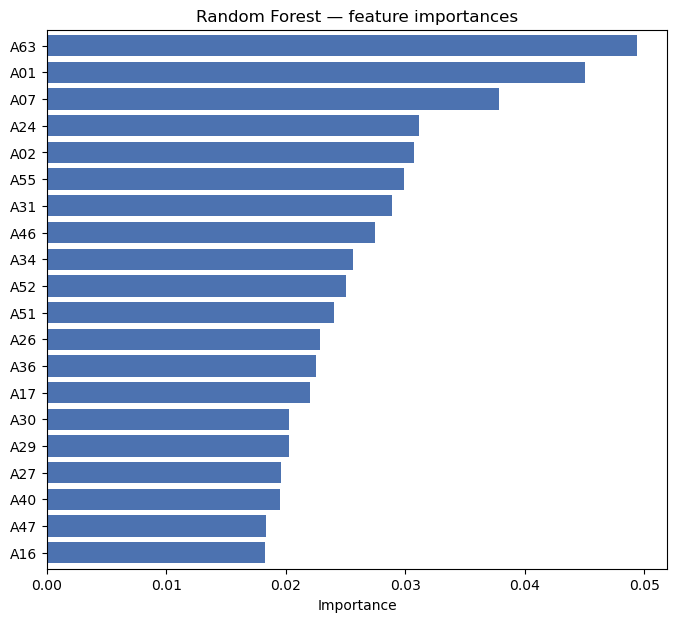

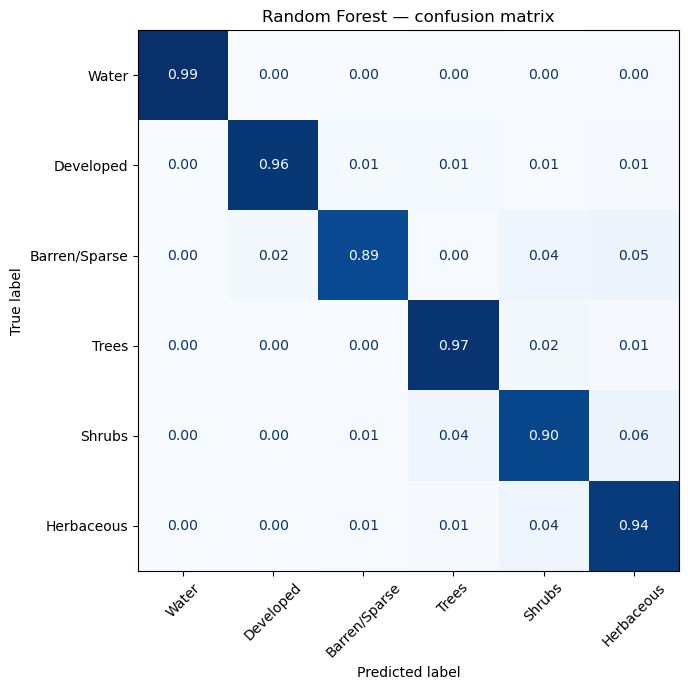

In [8]:
# ── Random Forest ────────────────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = ""
filename = f'random_forest_model{filename_ext}.joblib'

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_random_forest(x_train, y_train)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'random_forest_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'random_forest_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest — feature importances',
    save_path=os.path.join(MODEL_DIR, f'random_forest_importances{filename_ext}.png'))
rf_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Random Forest — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'random_forest_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (RF has no epochs -> validation curve instead) ────────────
if refit_models:
    groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]
    vc_param, vc_train, vc_val = rf_validation_curve(
        x_train, y_train, groups_train, param_name='min_samples_leaf',
        param_range=(1, 2, 4, 8, 16))
    plot_validation_curve(
        vc_param, vc_train, vc_val, param_name='min_samples_leaf', scoring='macro F1',
        title='Random Forest — validation curve',
        save_path=os.path.join(MODEL_DIR, f'random_forest_valcurve{filename_ext}.png'))


### XGBoost

Gradient-boosted trees on the same 64 embeddings, with inverse-frequency sample weights for the class imbalance. A grouped validation split records the per-boosting-round loss curve.

Training time: 2.03 seconds
               precision    recall  f1-score   support

        Water      0.987     0.983     0.985       841
    Developed      0.977     0.955     0.966      1153
Barren/Sparse      0.917     0.895     0.906       882
        Trees      0.974     0.968     0.971      5054
       Shrubs      0.783     0.878     0.828      1576
   Herbaceous      0.965     0.948     0.957      6523

     accuracy                          0.947     16029
    macro avg      0.934     0.938     0.935     16029
 weighted avg      0.949     0.947     0.948     16029

Overall accuracy : 0.947
Balanced accuracy: 0.938
Macro F1         : 0.935
Cohen's kappa    : 0.926
MCC              : 0.926


<Axes: title={'center': 'XGBoost — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

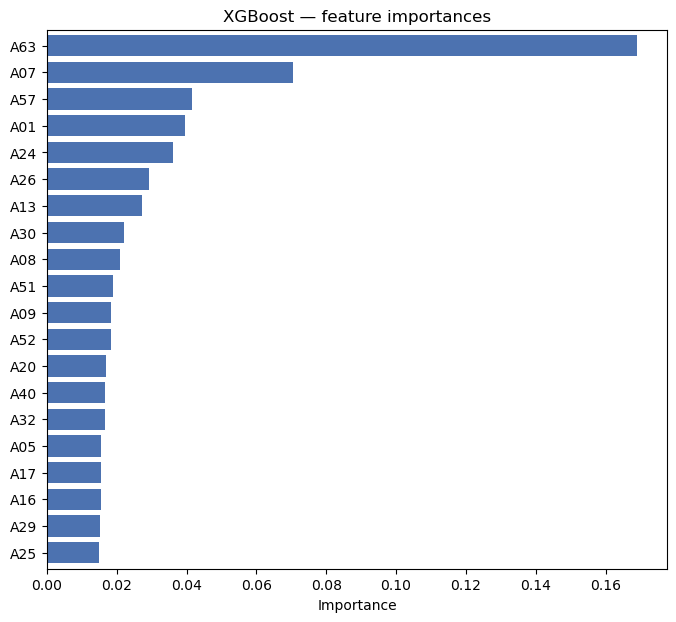

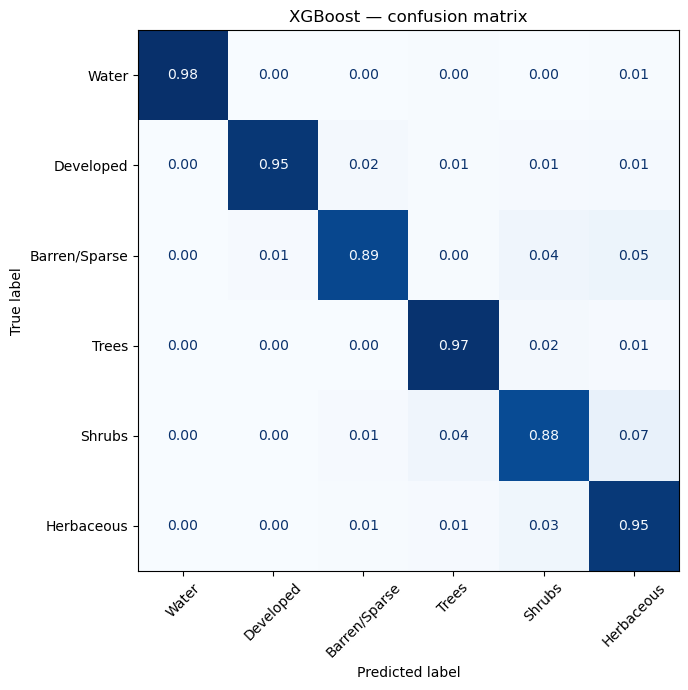

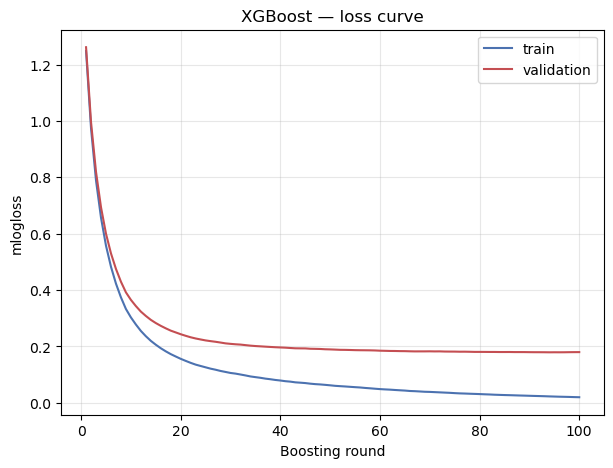

In [10]:
# ── XGBoost ──────────────────────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = ""
filename = f'XGBoost_model{filename_ext}.joblib'

# ── Glance_ID groups (grouped val split for the boosting-round loss curve) ───────────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_xgboost(x_train, y_train, groups=groups_train)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'XGBoost_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'XGBoost_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='XGBoost — feature importances',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_importances{filename_ext}.png'))
xgb_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='XGBoost — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost — loss curve',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_losscurve{filename_ext}.png'))


### Random Forest (tuned)

The random forest with hyperparameters chosen by a grouped-CV randomized search (`max_depth`, `min_samples_leaf`, `max_features`, ...), selected on macro-F1 so the rare classes carry weight.

Search time: 717.81 seconds
               precision    recall  f1-score   support

        Water      0.988     0.985     0.986       841
    Developed      0.970     0.959     0.965      1153
Barren/Sparse      0.922     0.884     0.903       882
        Trees      0.972     0.968     0.970      5054
       Shrubs      0.771     0.893     0.828      1576
   Herbaceous      0.968     0.941     0.954      6523

     accuracy                          0.945     16029
    macro avg      0.932     0.939     0.934     16029
 weighted avg      0.948     0.945     0.946     16029

Overall accuracy : 0.945
Balanced accuracy: 0.939
Macro F1         : 0.934
Cohen's kappa    : 0.924
MCC              : 0.924


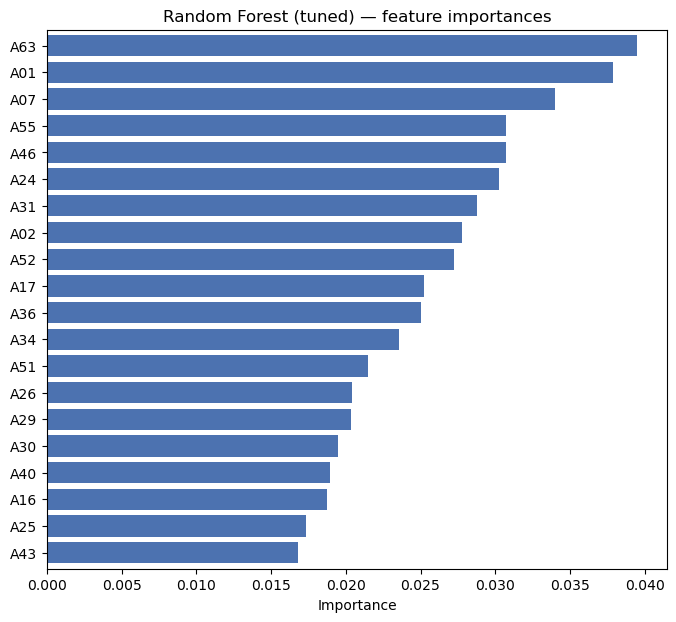

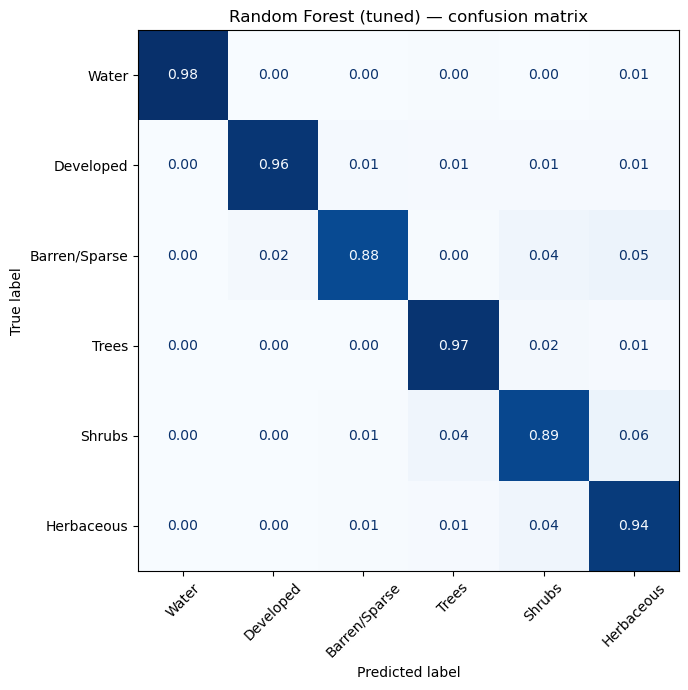

In [11]:
# ── Random Forest (grouped-CV tuned) ─────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = "_groupedCV"
filename = f'random_forest_tuned_model{filename_ext}.joblib'

# ── Glance_ID groups (so no segment spans CV folds) ──────────────────────────────────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec, best_params = tune_random_forest(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'random_forest_tuned_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
        f.write(f'best_params: {best_params}\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'random_forest_tuned_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest (tuned) — feature importances',
    save_path=os.path.join(MODEL_DIR, f'random_forest_tuned_importances{filename_ext}.png'))
rf_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Random Forest (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'random_forest_tuned_confusion{filename_ext}.png'))


### XGBoost (tuned)

Grouped-CV randomized search over tree depth, learning rate, subsampling, and regularization (`gamma`, `reg_alpha`, `max_delta_step`). `n_estimators` is not tuned — the winning parameters are refit with early stopping, so the number of boosting rounds is chosen by validation loss.

Search time: 127.77 seconds
Early stopping chose best_iteration=437 (of up to 2000 rounds)
               precision    recall  f1-score   support

        Water      0.985     0.987     0.986       841
    Developed      0.979     0.965     0.972      1153
Barren/Sparse      0.910     0.897     0.903       882
        Trees      0.974     0.971     0.972      5054
       Shrubs      0.799     0.882     0.839      1576
   Herbaceous      0.968     0.950     0.959      6523

     accuracy                          0.950     16029
    macro avg      0.936     0.942     0.939     16029
 weighted avg      0.952     0.950     0.951     16029

Overall accuracy : 0.950
Balanced accuracy: 0.942
Macro F1         : 0.939
Cohen's kappa    : 0.930
MCC              : 0.930


<Axes: title={'center': 'XGBoost (tuned) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

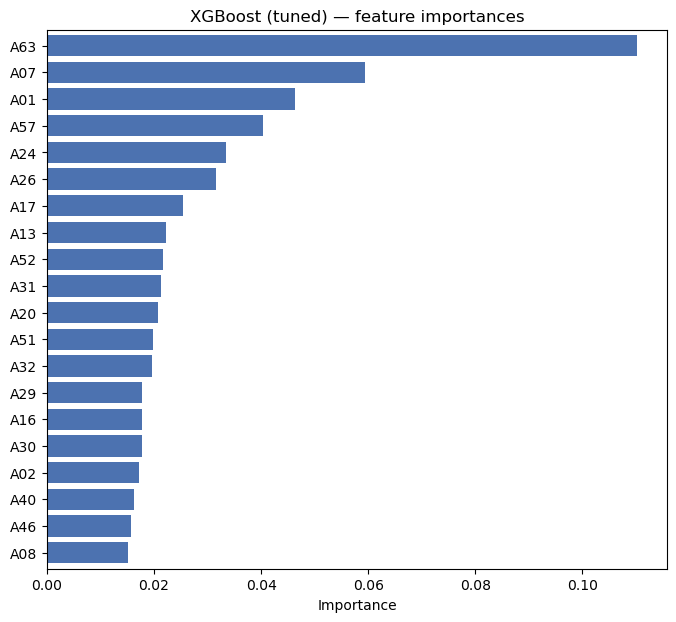

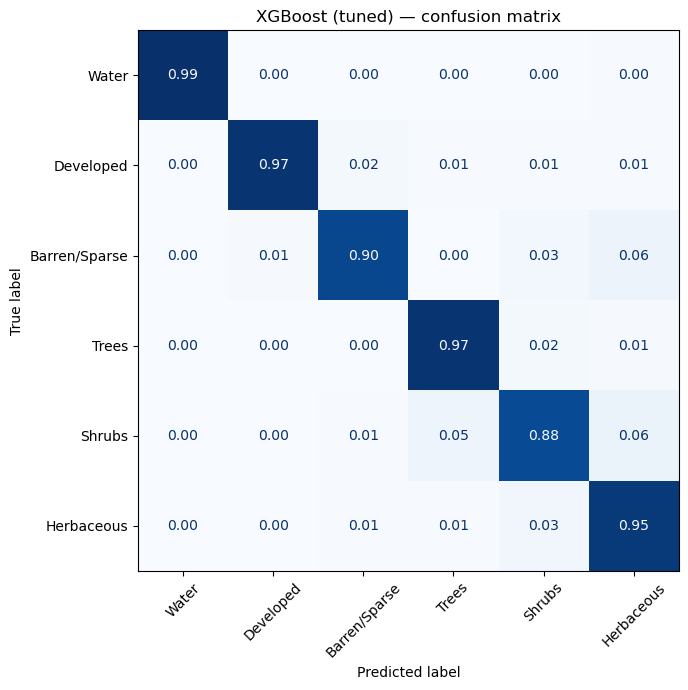

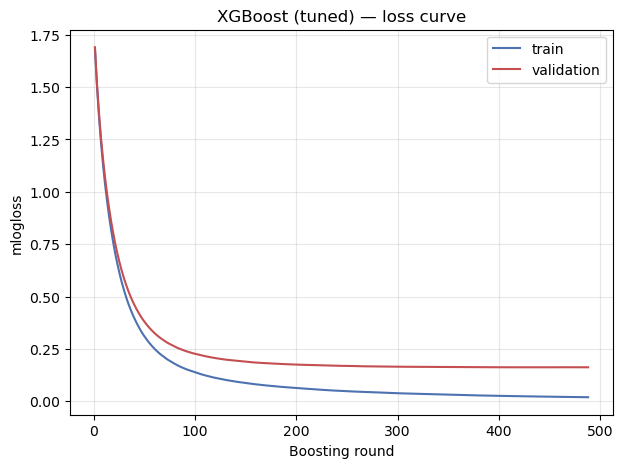

In [12]:
# ── XGBoost (grouped-CV tuned) ───────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = "_groupedCV"
filename = f'XGBoost_tuned_model{filename_ext}.joblib'

# ── Glance_ID groups (so no segment spans CV folds) ──────────────────────────────────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec, best_params = tune_xgboost(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'XGBoost_tuned_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
        f.write(f'best_params: {best_params}\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'XGBoost_tuned_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train, title='XGBoost (tuned) — feature importances',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_importances{filename_ext}.png'))
xgb_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='XGBoost (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val mlogloss; early stopping trims rounds) ──────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_losscurve{filename_ext}.png'))


### XGBoost (spatial)

The tuned XGBoost given spatial context: alongside each point's 64 center-pixel embeddings it also receives every band's neighborhood mean and standard deviation over the 5×5 window (192 features total). The statistics are derived from the cached patches when available, so no extra Earth Engine sampling is needed.

Loaded cached nbhd_features from Data/nbhd_features_r2.parquet: (64004, 128)
Search time: 525.56 seconds
Early stopping chose best_iteration=413 (of up to 2000 rounds)
               precision    recall  f1-score   support

        Water      0.986     0.985     0.985       841
    Developed      0.972     0.964     0.968      1153
Barren/Sparse      0.909     0.885     0.897       882
        Trees      0.973     0.969     0.971      5054
       Shrubs      0.790     0.866     0.827      1576
   Herbaceous      0.964     0.950     0.957      6523

     accuracy                          0.947     16029
    macro avg      0.932     0.936     0.934     16029
 weighted avg      0.948     0.947     0.947     16029

Overall accuracy : 0.947
Balanced accuracy: 0.936
Macro F1         : 0.934
Cohen's kappa    : 0.926
MCC              : 0.926


<Axes: title={'center': 'XGBoost (spatial) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

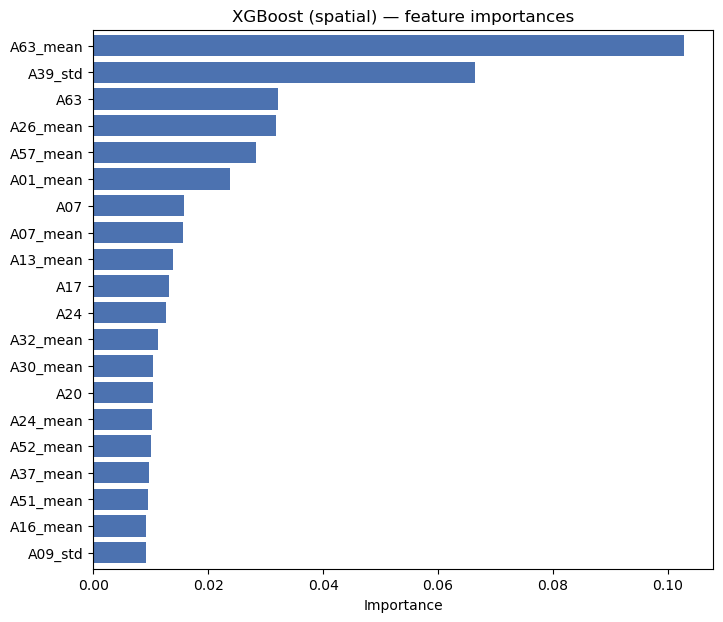

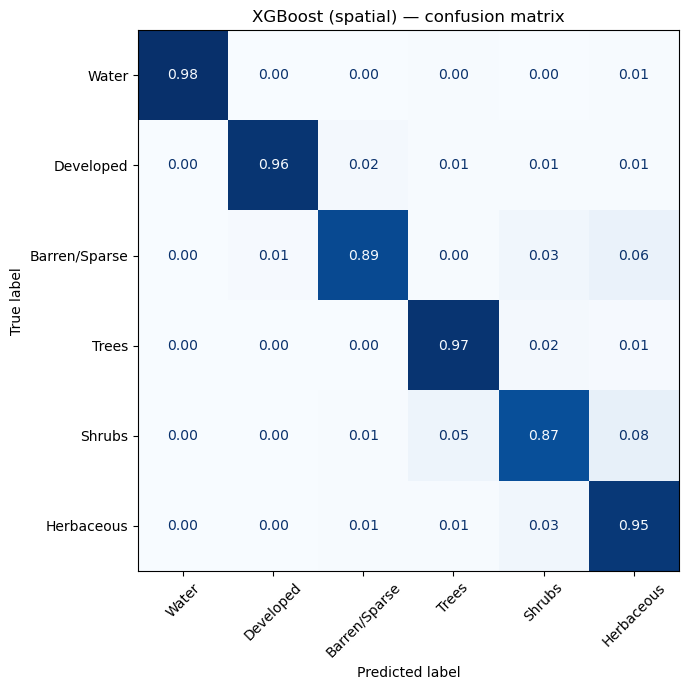

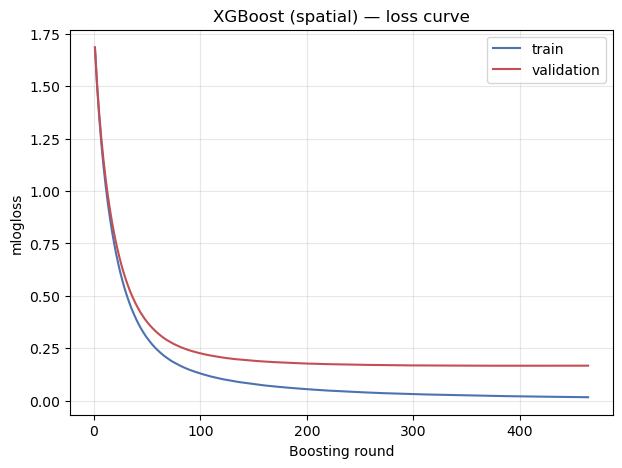

In [13]:
# ── XGBoost (spatial) ────────────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = "_spatial"
filename = f'XGBoost_nbhd_tuned_model{filename_ext}.joblib'

# ── Neighborhood mean/std features (cached to Data/, reloaded if present) ────────────
nbhd_path = os.path.join('Data', f'nbhd_features_r{patch_radius}.parquet')
if os.path.exists(nbhd_path):
    nbhd_features = pd.read_parquet(nbhd_path)
    print(f'Loaded cached nbhd_features from {nbhd_path}: {nbhd_features.shape}')
if not os.path.exists(nbhd_path) or len(nbhd_features) != len(expanded_Glance_Class1):
    nbhd_features = neighborhood_stats(X_patch_all)
    nbhd_features.to_parquet(nbhd_path)
    print(f'Saved nbhd_features to {nbhd_path}: {nbhd_features.shape}')

# ── Build the 192-feature tables on the existing train/test split ────────────────────
nbhd_features.index = expanded_Glance_Class1.index
x_train_nbhd = pd.concat([x_train, nbhd_features.loc[x_train.index]], axis=1)
x_test_nbhd = pd.concat([x_test, nbhd_features.loc[x_test.index]], axis=1)
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec, best_params = tune_xgboost(x_train_nbhd, y_train, groups_train)
    print(f'Best params: {best_params}')
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'XGBoost_nbhd_tuned_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
        f.write(f'best_params: {best_params}\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'XGBoost_nbhd_tuned_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train_nbhd, title='XGBoost (spatial) — feature importances',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_nbhd_tuned_importances{filename_ext}.png'))
xgb_nbhd_tuned_metrics = evaluate_model(
    mdl, x_test_nbhd, y_test, class_map=class1_dict,
    title='XGBoost (spatial) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_nbhd_tuned_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val mlogloss per boosting round) ────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (spatial) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_nbhd_tuned_losscurve{filename_ext}.png'))


### Shallow MLP

A small neural network (64 → 128 → 64 → classes) trained on the embeddings for a fixed number of epochs with a class-weighted loss. Records a train/validation loss curve for the overfitting diagnostic.

Training time: 73.09 seconds
               precision    recall  f1-score   support

        Water      0.966     0.993     0.979       841
    Developed      0.964     0.970     0.967      1153
Barren/Sparse      0.847     0.908     0.876       882
        Trees      0.979     0.960     0.970      5054
       Shrubs      0.720     0.905     0.802      1576
   Herbaceous      0.978     0.917     0.946      6523

     accuracy                          0.937     16029
    macro avg      0.909     0.942     0.923     16029
 weighted avg      0.944     0.937     0.939     16029

Overall accuracy : 0.937
Balanced accuracy: 0.942
Macro F1         : 0.923
Cohen's kappa    : 0.913
MCC              : 0.914


<Axes: title={'center': 'Shallow MLP — loss curve'}, xlabel='Epoch', ylabel='Loss'>

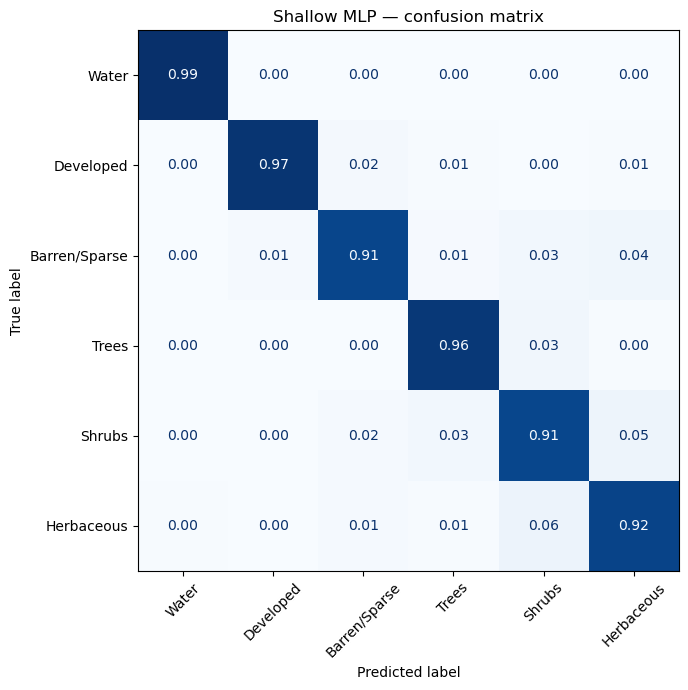

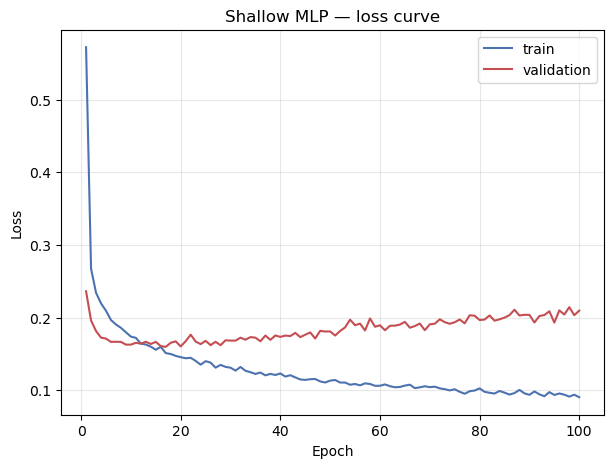

In [14]:
# ── Shallow MLP ──────────────────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = ""
filename = f'MLP_model{filename_ext}.joblib'

# ── Glance_ID groups (grouped val split for the loss curve) ──────────────────────────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_mlp(x_train, y_train, groups=groups_train, verbose=True, epochs=100)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate (no feature importances for an MLP) ─────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
mlp_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Shallow MLP — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'MLP_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val loss per epoch) ─────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP — loss curve',
    save_path=os.path.join(MODEL_DIR, f'MLP_losscurve{filename_ext}.png'))
#Overfitting observed with validation loss increasing as more epochs are run

### Shallow MLP (early stopping)

The same MLP trained with a high epoch cap and early stopping: training halts once validation loss stops improving and the best-epoch weights are restored, to curb overfitting.

Training time: 22.46 seconds
Early stopping restored best epoch 17
               precision    recall  f1-score   support

        Water      0.968     0.994     0.981       841
    Developed      0.948     0.975     0.961      1153
Barren/Sparse      0.851     0.899     0.874       882
        Trees      0.984     0.949     0.966      5054
       Shrubs      0.694     0.901     0.784      1576
   Herbaceous      0.975     0.916     0.945      6523

     accuracy                          0.932     16029
    macro avg      0.903     0.939     0.919     16029
 weighted avg      0.941     0.932     0.935     16029

Overall accuracy : 0.932
Balanced accuracy: 0.939
Macro F1         : 0.919
Cohen's kappa    : 0.907
MCC              : 0.908


<Axes: title={'center': 'Shallow MLP (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

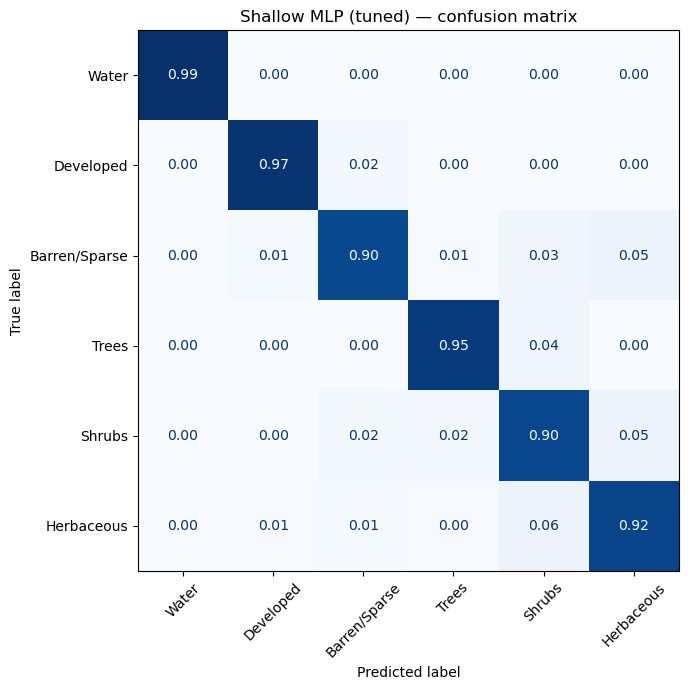

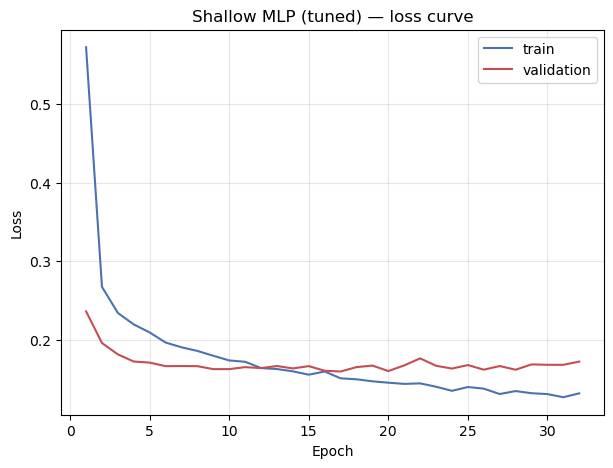

In [15]:
# ── Shallow MLP (early stopping) ─────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = "_tuned"
filename = f'MLP_model{filename_ext}.joblib'

# ── Glance_ID groups (grouped val split to early-stop on) ────────────────────────────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_mlp(x_train, y_train, groups=groups_train,
                                     early_stopping_rounds=15, epochs=300, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
mlp_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Shallow MLP (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'MLP_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ──────
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'MLP_losscurve{filename_ext}.png'))


### CNN (embedding patches)

A small convolutional network that sees the 5×5×64 neighborhood window around each point instead of a single pixel, so it can learn spatial texture and context. Trained for a fixed number of epochs.

Training time: 72.31 seconds
               precision    recall  f1-score   support

        Water      0.970     0.995     0.982       841
    Developed      0.962     0.955     0.958      1153
Barren/Sparse      0.865     0.912     0.887       882
        Trees      0.977     0.960     0.969      5054
       Shrubs      0.740     0.876     0.802      1576
   Herbaceous      0.969     0.930     0.949      6523

     accuracy                          0.938     16029
    macro avg      0.914     0.938     0.925     16029
 weighted avg      0.943     0.938     0.940     16029

Overall accuracy : 0.938
Balanced accuracy: 0.938
Macro F1         : 0.925
Cohen's kappa    : 0.915
MCC              : 0.915


<Axes: title={'center': 'CNN (patches) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

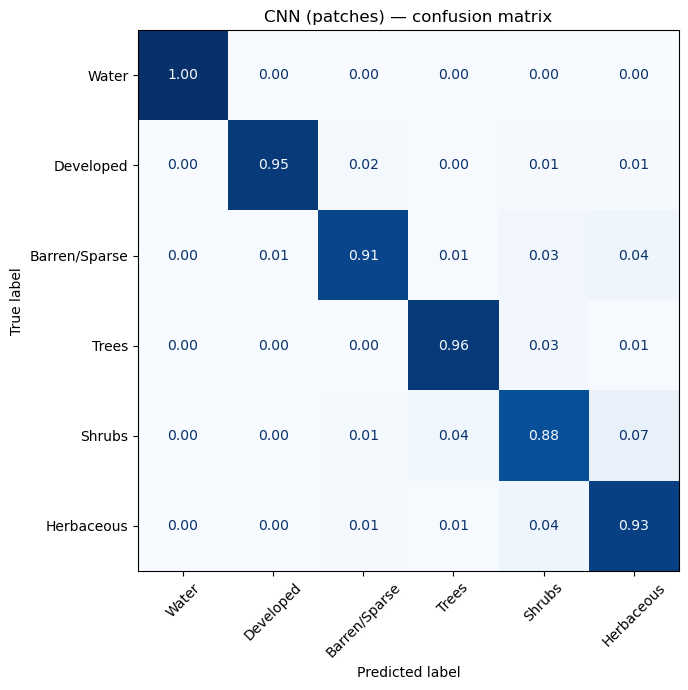

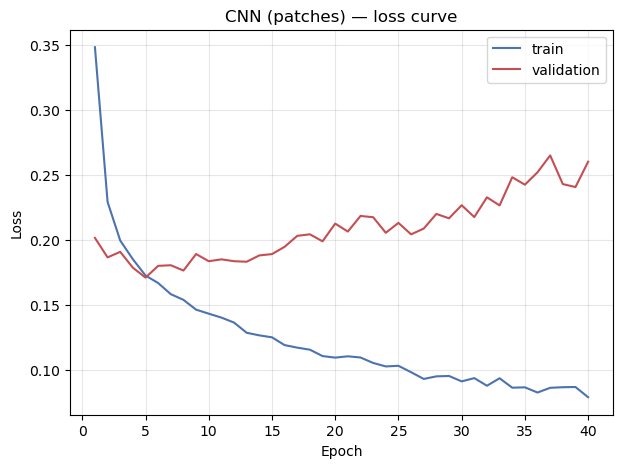

In [16]:
# ── CNN (embedding patches) ──────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = ""
filename = f'CNN_model{filename_ext}.joblib'

# ── Glance_ID groups (aligned to patch rows; grouped val split for the loss curve) ───
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_cnn(X_train_patch, y_train, groups=groups_train, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate (no feature importances for a CNN) ──────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
cnn_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class1_dict,
    title='CNN (patches) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'CNN_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val loss per epoch) ─────────────────────────────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (patches) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'CNN_losscurve{filename_ext}.png'))
#Significant overfitting observed with validation loss increasing as more epochs are run

### CNN (early stopping)

The same CNN with a high epoch cap and early stopping — training halts when validation loss plateaus and the best-epoch weights are restored.

Training time: 34.18 seconds
Early stopping restored best epoch 5
               precision    recall  f1-score   support

        Water      0.975     0.994     0.985       841
    Developed      0.945     0.963     0.954      1153
Barren/Sparse      0.824     0.923     0.871       882
        Trees      0.977     0.959     0.968      5054
       Shrubs      0.703     0.888     0.785      1576
   Herbaceous      0.976     0.907     0.940      6523

     accuracy                          0.931     16029
    macro avg      0.900     0.939     0.917     16029
 weighted avg      0.939     0.931     0.933     16029

Overall accuracy : 0.931
Balanced accuracy: 0.939
Macro F1         : 0.917
Cohen's kappa    : 0.905
MCC              : 0.906


<Axes: title={'center': 'CNN (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

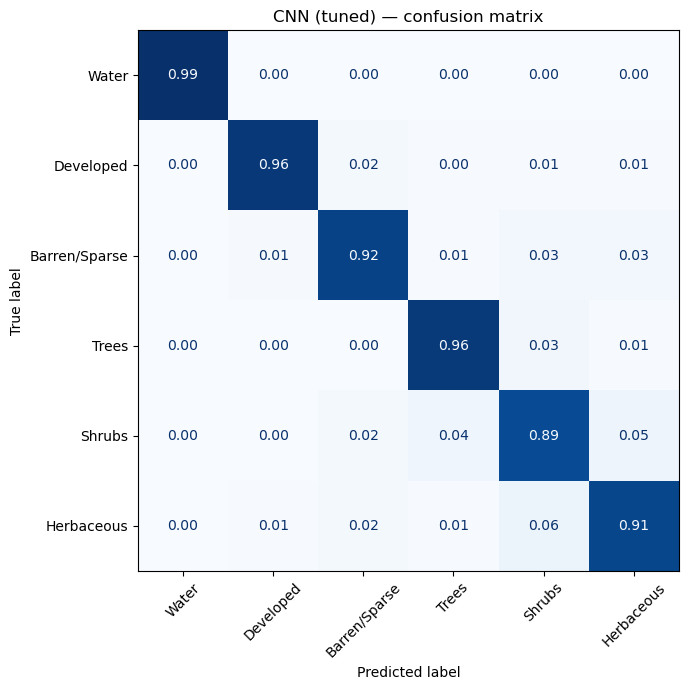

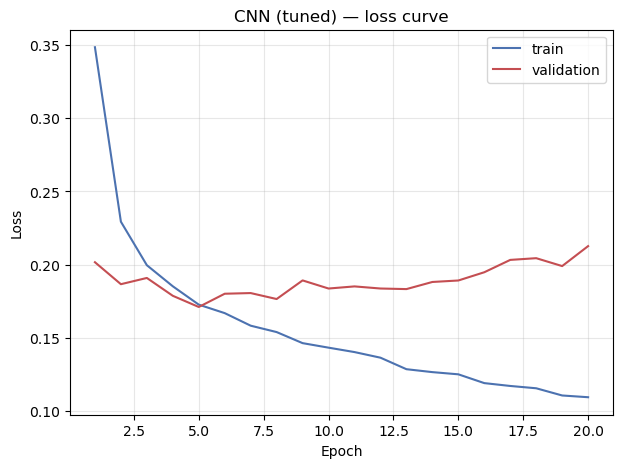

In [17]:
# ── CNN (early stopping) ─────────────────────────────────────────────────────────────
# ── Variant filename ─────────────────────────────────────────────────────────────────
filename_ext = "_tuned"
filename = f'CNN_model{filename_ext}.joblib'

# ── Glance_ID groups (aligned to patch rows; grouped val split to early-stop on) ─────
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load ──────────────────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_cnn(X_train_patch, y_train, groups=groups_train,
                                     early_stopping_rounds=15, epochs=200, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ─────────────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
cnn_tuned_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class1_dict,
    title='CNN (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'CNN_confusion{filename_ext}.png'))

# ── Overfitting diagnostic (train vs val loss per epoch; stops near best epoch) ──────
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'CNN_losscurve{filename_ext}.png'))


## Class Distribution

Level-1 class counts in the full modeling dataset (per-year observations) and within Washington / Oregon, to contextualize the model-comparison results that follow.

In [19]:
# ── Class Counts (full dataset vs Washington/Oregon) ─────────────────────────────────
# Level-1 class name for every per-year observation.
class1_names = expanded_Glance_Class1['Glance_Class_ID_level1'].map(class1_dict)

# ── State of each observation via point-in-polygon (WA/OR TIGER polygons) ────────────
wa_or_fc = (ee.FeatureCollection('TIGER/2018/States')
            .filter(ee.Filter.inList('NAME', ['Washington', 'Oregon'])))
wa_or_states = gpd.GeoDataFrame.from_features(
    wa_or_fc.getInfo()['features'], crs='EPSG:4326')[['NAME', 'geometry']]
pts = gpd.GeoDataFrame(
    expanded_Glance_Class1[['Glance_ID']].copy(),
    geometry=gpd.points_from_xy(expanded_Glance_Class1['Lon'], expanded_Glance_Class1['Lat']),
    crs='EPSG:4326')
joined = gpd.sjoin(pts, wa_or_states, predicate='within', how='left')
joined = joined[~joined.index.duplicated(keep='first')]  # guard against border points matching both
state_of = joined['NAME'].reindex(expanded_Glance_Class1.index)

# ── Counts (rows ordered by Level-1 class id, with a Total row) ──────────────────────
class_order = [class1_dict[k] for k in sorted(class1_dict)]
counts = pd.DataFrame({
    'Full dataset': class1_names.value_counts(),
    'Washington': class1_names[state_of == 'Washington'].value_counts(),
    'Oregon': class1_names[state_of == 'Oregon'].value_counts(),
}).reindex(class_order).fillna(0).astype(int)
counts['WA + OR'] = counts['Washington'] + counts['Oregon']
counts.loc['Total'] = counts.sum()

# ── Format each count with its within-column percentage: "count (pct%)" ──────────────
col_totals = counts.loc['Total']
class_counts = counts.apply(lambda col: col.map(
    lambda v: f'{v:,} ({v / col_totals[col.name] * 100:.1f}%)' if col_totals[col.name] else f'{v:,}'))

print('Level-1 class counts (per-year observations), % within each column:')
display(class_counts)


Level-1 class counts (per-year observations), % within each column:


,Full dataset,Washington,Oregon,WA + OR
Glance_Class_ID_level1,,,,
Water,"3,169 (5.0%)",46 (3.4%),13 (0.7%),59 (1.9%)
Ice/Snow,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Developed,"4,629 (7.2%)",89 (6.7%),95 (5.4%),184 (5.9%)
Barren/Sparse,"3,462 (5.4%)",62 (4.6%),178 (10.1%),240 (7.7%)
Trees,"20,049 (31.3%)",530 (39.6%),512 (28.9%),"1,042 (33.5%)"
Shrubs,"6,590 (10.3%)",90 (6.7%),320 (18.1%),410 (13.2%)
Herbaceous,"26,105 (40.8%)",521 (38.9%),651 (36.8%),"1,172 (37.7%)"
Total,"64,004 (100.0%)","1,338 (100.0%)","1,769 (100.0%)","3,107 (100.0%)"


## Model Comparison

Load every saved model and compare them on the shared test set, then on the Washington/Oregon subset. Every metric below except training time ranges 0–1 with higher being better:

- **Accuracy** — fraction of all test observations classified correctly. Simple, but dominated by the common classes when the data is imbalanced.
- **Balanced accuracy** — the average of per-class recall, so every class counts equally regardless of size; corrects accuracy's majority-class bias.
- **Macro F1** — the unweighted mean of per-class F1 (the harmonic mean of precision and recall). The primary metric here, since it weights rare and common classes equally.
- **Weighted F1** — per-class F1 averaged by class frequency; reflects typical performance across the actual class mix.
- **Cohen's kappa** — agreement corrected for chance (0 = random, 1 = perfect); a chance-adjusted alternative to accuracy.
- **MCC** — Matthews correlation coefficient between predicted and true labels (−1 to 1); robust under imbalance and only high when the model does well across all classes.
- **Training time (s)** — wall-clock time to fit or search the model; lower is better.

A separate **per-class F1** table and heatmap break F1 down by individual land-cover class to show which classes each model handles well.

=== Summary metrics (saved to model_comparison_summary.csv) ===


,Accuracy,Balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.9456,0.9394,0.9346,0.9466,0.9243,0.9245,12.34
XGBoost,0.9471,0.9379,0.9354,0.9479,0.9262,0.9263,2.03
RF (tuned),0.9455,0.9385,0.9343,0.9464,0.9241,0.9243,717.81
XGBoost (tuned),0.9501,0.9420,0.9386,0.9507,0.9304,0.9305,127.77
MLP,0.9369,0.9423,0.9235,0.9389,0.9128,0.9137,73.09
MLP (tuned),0.9324,0.9390,0.9185,0.9349,0.9067,0.9078,22.46
CNN,0.9384,0.9379,0.9246,0.9399,0.9146,0.9150,72.31
CNN (tuned),0.9309,0.9389,0.9170,0.9332,0.9047,0.9058,34.18
XGBoost (spatial),0.9468,0.9364,0.9340,0.9474,0.9258,0.9259,525.56



=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,0.9881,0.9851,0.9863,0.9857,0.9795,0.9806,0.9824,0.9847,0.9851
Developed,0.9638,0.9658,0.9647,0.9721,0.9667,0.9611,0.9582,0.9540,0.9678
Barren/Sparse,0.9009,0.9059,0.9028,0.9035,0.8764,0.8743,0.8874,0.8706,0.8972
Trees,0.9699,0.9710,0.9700,0.9723,0.9695,0.9663,0.9686,0.9678,0.9707
Shrubs,0.8304,0.8280,0.8275,0.8386,0.8024,0.7843,0.8019,0.7846,0.8265
Herbaceous,0.9543,0.9566,0.9544,0.9592,0.9464,0.9447,0.9494,0.9405,0.9569


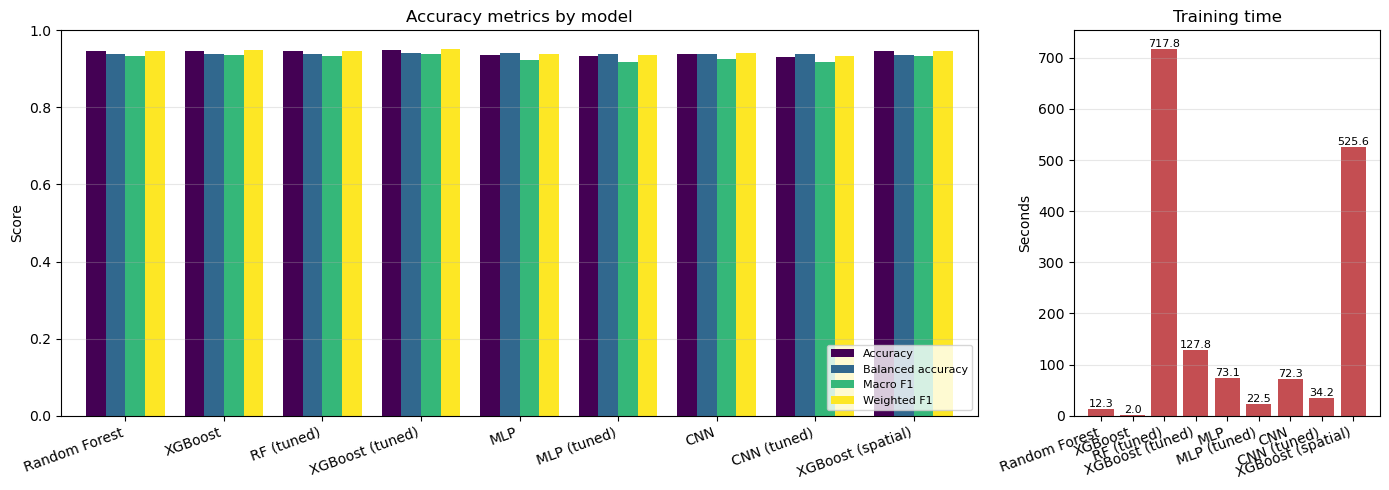

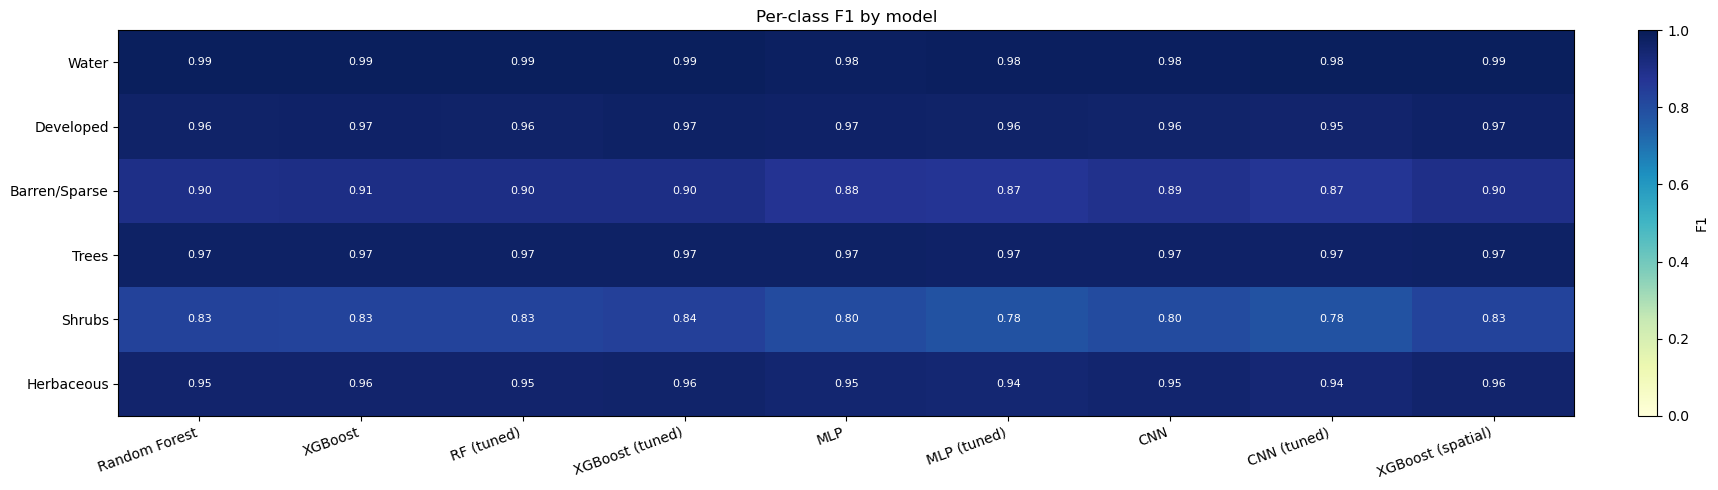

In [51]:
# ── Compare Models ───────────────────────────────────────────────────────────────────
# Load every saved model + its training time and compare on the shared held-out test set.
def _load_training_time(time_filename):
    with open(os.path.join(MODEL_DIR, time_filename)) as f:
        return float(f.read().split()[0])  # first token of "<seconds> seconds"

# ── Models on the shared single-pixel x_test ─────────────────────────────────────────
model_files = {
    'Random Forest':   ('random_forest_model.joblib',                  'random_forest_training_time.txt'),
    'XGBoost':         ('XGBoost_model.joblib',                        'XGBoost_training_time.txt'),
    'RF (tuned)':      ('random_forest_tuned_model_groupedCV.joblib',  'random_forest_tuned_training_time_groupedCV.txt'),
    'XGBoost (tuned)': ('XGBoost_tuned_model_groupedCV.joblib',        'XGBoost_tuned_training_time_groupedCV.txt'),
    'MLP':             ('MLP_model.joblib',                            'MLP_training_time.txt'),
    'MLP (tuned)':     ('MLP_model_tuned.joblib',                      'MLP_training_time_tuned.txt'),
}
models = {}
for name, (model_file, time_file) in model_files.items():
    models[name] = (joblib.load(os.path.join(MODEL_DIR, model_file)), _load_training_time(time_file))

# ── Models with a different input (pass their own test set as a 3-tuple) ─────────────
cnn_model = joblib.load(os.path.join(MODEL_DIR, 'CNN_model.joblib'))
models['CNN'] = (cnn_model, _load_training_time('CNN_training_time.txt'), X_test_patch)
cnn_tuned_model = joblib.load(os.path.join(MODEL_DIR, 'CNN_model_tuned.joblib'))
models['CNN (tuned)'] = (cnn_tuned_model, _load_training_time('CNN_training_time_tuned.txt'), X_test_patch)
xgb_spatial_model = joblib.load(os.path.join(MODEL_DIR, 'XGBoost_nbhd_tuned_model_spatial.joblib'))
models['XGBoost (spatial)'] = (xgb_spatial_model, _load_training_time('XGBoost_nbhd_tuned_training_time_spatial.txt'), x_test_nbhd)

# ── Compare and display ──────────────────────────────────────────────────────────────
summary_df, per_class_f1_df = compare_models(
    models, x_test, y_test, class_map=class1_dict,
    save_dir=MODEL_DIR, prefix='model_comparison')
print('=== Summary metrics (saved to model_comparison_summary.csv) ===')
display(summary_df.round(4))
print('\n=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===')
display(per_class_f1_df.round(4))


WA/OR observations by split:
  Training: 2354 of 47975 (WA=1017, OR=1337)
  Test:     753 of 16029 (WA=321, OR=432)

Evaluating on 753 WA/OR test observations...

=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===


,Accuracy,Balanced accuracy,Macro F1,Weighted F1,Cohen's kappa,MCC,Training time (s)
Random Forest,0.9363,0.9376,0.9348,0.9372,0.9124,0.9128,12.34
XGBoost,0.9376,0.9151,0.9227,0.9383,0.9140,0.9143,2.03
RF (tuned),0.9336,0.9387,0.9328,0.9352,0.9091,0.9099,717.81
XGBoost (tuned),0.9376,0.9340,0.9334,0.9388,0.9142,0.9146,127.77
MLP,0.9203,0.9315,0.9221,0.9238,0.8914,0.8932,73.09
MLP (tuned),0.9031,0.9261,0.9023,0.9074,0.8688,0.8719,22.46
CNN,0.9349,0.9315,0.9274,0.9363,0.9107,0.9112,72.31
CNN (tuned),0.9031,0.9245,0.9020,0.9066,0.8689,0.8718,34.18
XGBoost (spatial),0.9323,0.9262,0.9265,0.9337,0.9070,0.9073,525.56



=== WA/OR per-class F1 ===


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned),XGBoost (spatial)
Water,1.0000,0.9375,1.0000,1.0000,1.0000,0.9714,1.0000,1.0000,0.9697
Developed,0.9293,0.9091,0.9293,0.9293,0.9109,0.9126,0.9091,0.9109,0.9320
Barren/Sparse,0.9457,0.9375,0.9457,0.9365,0.9683,0.9242,0.9147,0.8794,0.9440
Trees,0.9819,0.9839,0.9778,0.9819,0.9817,0.9734,0.9879,0.9736,0.9818
Shrubs,0.8205,0.8290,0.8119,0.8122,0.7570,0.7364,0.8182,0.7512,0.8020
Herbaceous,0.9312,0.9391,0.9324,0.9403,0.9145,0.8956,0.9348,0.8969,0.9295


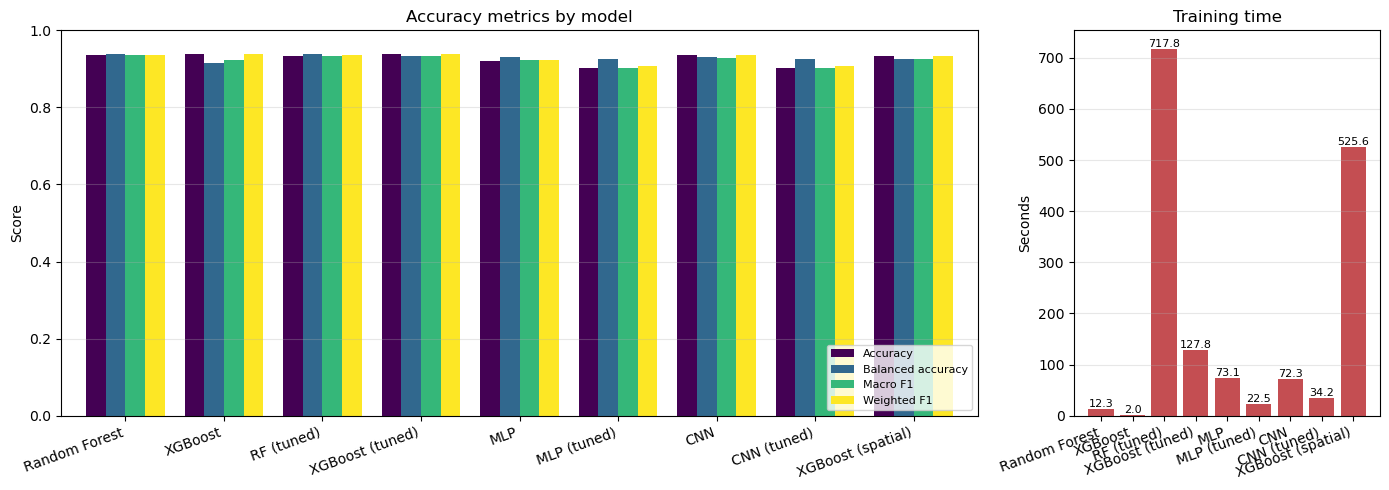

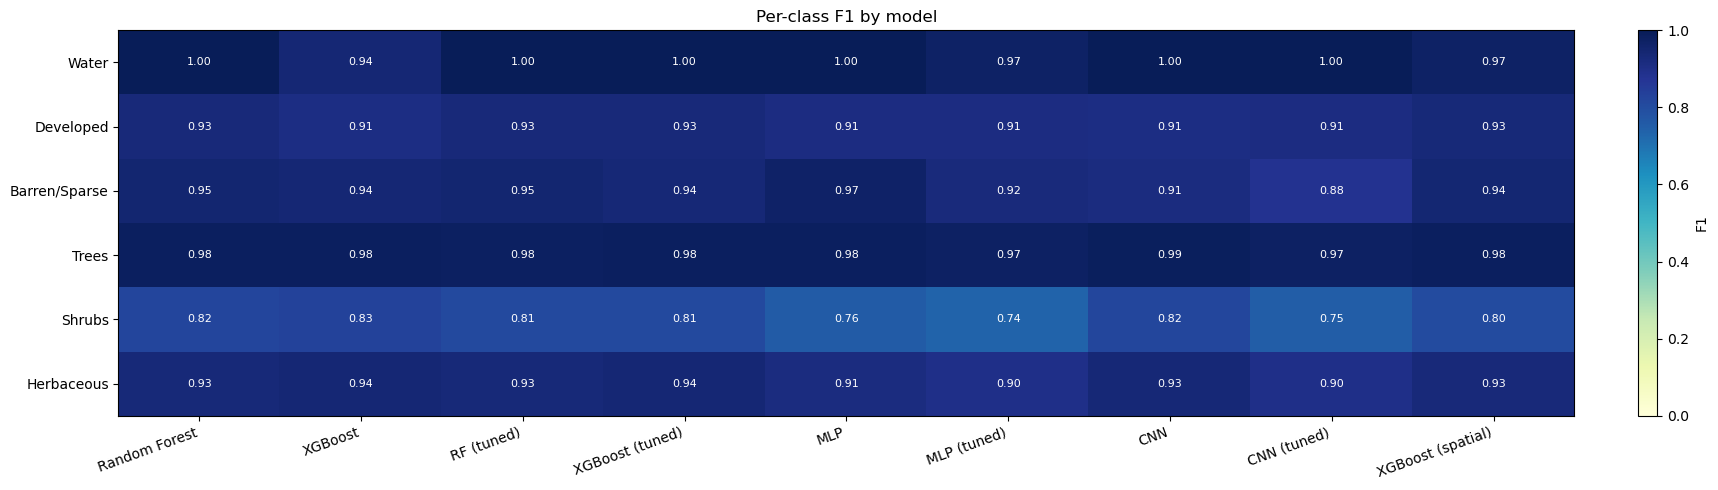

In [52]:
# ── Compare Models — Washington/Oregon subset ────────────────────────────────────────
# How many WA/OR observations are in train vs test, and how well do the models predict
# the WA/OR observations within the test set? Reuses the models loaded above.

# ── WA/OR polygons (same TIGER source as the Extra cell) ─────────────────────────────
wa_or_fc = (ee.FeatureCollection('TIGER/2018/States')
            .filter(ee.Filter.inList('NAME', ['Washington', 'Oregon'])))
wa_or_states = gpd.GeoDataFrame.from_features(
    wa_or_fc.getInfo()['features'], crs='EPSG:4326')[['NAME', 'geometry']]

# ── Point-in-polygon: label each Class1 row's state (aligned by index) ───────────────
pts = gpd.GeoDataFrame(
    expanded_Glance_Class1[['Glance_ID']].copy(),
    geometry=gpd.points_from_xy(expanded_Glance_Class1['Lon'], expanded_Glance_Class1['Lat']),
    crs='EPSG:4326')
joined = gpd.sjoin(pts, wa_or_states, predicate='within', how='left')
joined = joined[~joined.index.duplicated(keep='first')]  # guard against border points matching both
state_of = joined['NAME'].reindex(expanded_Glance_Class1.index)
in_wa_or = state_of.notna()

# ── Counts in train vs test ──────────────────────────────────────────────────────────
train_state, test_state = state_of.loc[x_train.index], state_of.loc[x_test.index]
print('WA/OR observations by split:')
print(f"  Training: {int(in_wa_or.loc[x_train.index].sum())} of {len(x_train)} "
      f"(WA={int((train_state == 'Washington').sum())}, OR={int((train_state == 'Oregon').sum())})")
print(f"  Test:     {int(in_wa_or.loc[x_test.index].sum())} of {len(x_test)} "
      f"(WA={int((test_state == 'Washington').sum())}, OR={int((test_state == 'Oregon').sum())})")

# ── Restrict the test set to WA/OR (mask is in x_test / X_test_patch row order) ──────
mask = in_wa_or.loc[x_test.index].values
x_test_wa_or = x_test[mask]
y_test_wa_or = y_test[mask]
X_test_patch_wa_or = X_test_patch[mask]

# ── Re-point the different-input models at the WA/OR subset of their test set ────────
models_wa_or = dict(models)
models_wa_or['CNN'] = (cnn_model, models['CNN'][1], X_test_patch_wa_or)
models_wa_or['CNN (tuned)'] = (cnn_tuned_model, models['CNN (tuned)'][1], X_test_patch_wa_or)
models_wa_or['XGBoost (spatial)'] = (xgb_spatial_model, models['XGBoost (spatial)'][1], x_test_nbhd[mask])

# ── Compare and display ──────────────────────────────────────────────────────────────
print(f'\nEvaluating on {int(mask.sum())} WA/OR test observations...')
summary_wa_or_df, per_class_wa_or_df = compare_models(
    models_wa_or, x_test_wa_or, y_test_wa_or, class_map=class1_dict,
    save_dir=MODEL_DIR, prefix='model_comparison_WA_OR')
print('\n=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===')
display(summary_wa_or_df.round(4))
print('\n=== WA/OR per-class F1 ===')
display(per_class_wa_or_df.round(4))


# Conclusions - Class 1

Overall, the tuned XGBoost model performs best. It achieves the highest values for all evaluation metrics in the North America–wide dataset and the highest values for most metrics in the Pacific Northwest dataset. The tuned Random Forest model has a slightly higher balanced accuracy in the Pacific Northwest dataset. In the North America–wide dataset, the tuned XGBoost model also achieves the highest F1 scores for all land cover classes except water and barren/sparse. As expected, all models perform better on the more common classes, such as trees, and less well on the rarer shrub class.

The tuned XGBoost model has similar values for overall accuracy, balanced accuracy, macro F1, and weighted F1, indicating that it performs consistently across classes. The slightly lower macro F1 score suggests that performance on the less common classes is somewhat weaker than on the more common classes. The confusion matrix shows that 2% of tree pixels and 3% of herbaceous pixels are incorrectly classified as shrubs. The largest sources of confusion are barren/sparse pixels being misclassified as herbaceous (6%) and shrub pixels being misclassified as either trees (5%) or herbaceous (6%). 

In [ ]:
#Extra (KEEP AND DON'T EDIT)

# Washington and Oregon boundaries from GEE (TIGER 2018 state boundaries).
states_fc = (ee.FeatureCollection('TIGER/2018/States')
    .filter(ee.Filter.inList('NAME', ['Washington', 'Oregon'])))
states = gpd.GeoDataFrame.from_features(
    states_fc.getInfo()['features'], crs='EPSG:4326'
)[['NAME', 'geometry']]

# glance is already loaded and in EPSG:4326 from the previous cell.
glance_wa_or = gpd.sjoin(glance, states, predicate='within', how='inner')

counts = glance_wa_or['NAME'].value_counts()
for state in ['Washington', 'Oregon']:
    print(f'{state}: {counts.get(state, 0)}')
print(f'Total (WA + OR): {len(glance_wa_or)}')

#glance_wa_or.head()
print(glance.columns)
glance_NA = glance.iloc[glance['Continent_Code']==1,]
print(glance_NA.shape)
print(glance_NA['Glance_Class_ID_level2'].value_counts())

print(glance_NA.shape[0])
Class1 = []
Class2 = []
for i in range(0,glance_NA.shape[0]):
    key = glance_NA['Glance_Class_ID_level1'].iloc[i]
    Class1 = Class1 + [class1_dict[key]]
    key2 = glance_NA['Glance_Class_ID_level2'].iloc[i]
    #print(class2_dict[key2])
    Class2 = Class2 + [class2_dict[key2]]
glance_NA['Class1'] = Class1
glance_NA['Class2'] = Class2
#print(glance_NA.head())
print(glance_NA['Class2'].value_counts())
#print(glance_NA['Glance_Class_ID_level2'].unique())
glance_NA_0 = glance_NA.iloc[glance_NA['Class2']=="Unknown",]
print(glance_NA_0['Class1'].value_counts())

print(glance_NA_filtered['Change'].value_counts())
test = glance_NA_filtered.iloc[glance_NA_filtered['Change'],]
#print(test.head())
test['End_Year'].value_counts()

counts = glance_NA_filtered[['Lat', 'Lon']].value_counts().reset_index(name='count')
print(counts['count'].value_counts())

test2 = glance_NA_filtered.iloc[glance_NA_filtered['Segment_Type']==0,]
print(test2['Change'].value_counts())

print(glance_NA_filtered['Change'].value_counts())
print(glance_NA_filtered.shape)
print(glance_NA_filtered['Class2'].value_counts())